Notebook to determine copy correction procedure from toy example. 

1. Start with toy example of fully synchronized reads. Show that we can transform from the equal total read count matrix to the copy number matrix.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Copy number matrix, each row is an origin
# each column is a timepoint
V = np.array([[2, 2, 2],
              [1, 2, 2],
              [1, 1, 2]])
n = V.shape[0]

# total copy number counts for each timepoint
counts = V.sum(axis=0)
counts_reshape = counts.reshape((1, -1))

# Transform to equal sum counts
V_prime = (V * n / counts_reshape)

# Reconstruct V to show the reverse transformation is possible
recontructed_V = V_prime * counts_reshape / n


Text(0.5, 1.0, 'Copy number counts\nreconstructed')

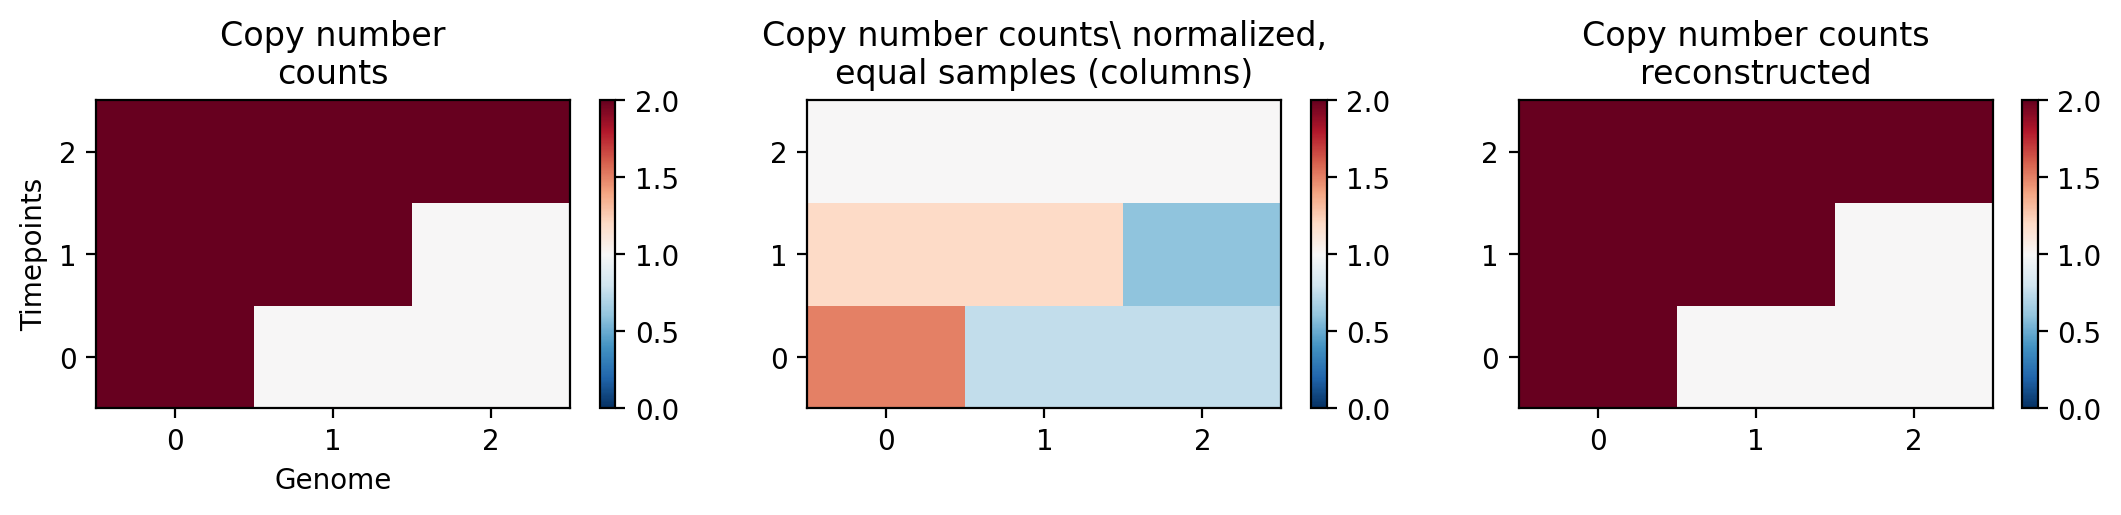

In [3]:
plt.figure(figsize=(13, 2))
plt.subplot(1, 3, 1)
plt.imshow(V.T, aspect='auto', cmap='RdBu_r', vmin=0, vmax=2, origin='lower')
plt.colorbar()
plt.title("Copy number\ncounts")
plt.ylabel("Timepoints")
plt.xlabel("Genome")

plt.subplot(1, 3, 2)
plt.imshow(V_prime.T, aspect='auto', cmap='RdBu_r', vmin=0, vmax=2, origin='lower')
plt.colorbar()
plt.title("Copy number counts\ normalized,\nequal samples (columns)")

plt.subplot(1, 3, 3)
plt.imshow(recontructed_V.T, aspect='auto', cmap='RdBu_r', vmin=0, vmax=2, origin='lower')
plt.colorbar()
plt.title("Copy number counts\nreconstructed")

In [4]:
# Let's take a replication profile and convert it into the equal sample example...
path = 'data/replication_timing/yl_2019/chrom_replication_timing_shared.csv'
chrom_repl_profile = pd.read_csv(path).set_index(['chr', 'start'])
chrom10_replication_profile = chrom_repl_profile.loc[10]

num_indices = 30
n = chrom10_replication_profile.shape[0]

copy_number_matrix = np.ones((n, num_indices))
    
for i in range(chrom10_replication_profile.shape[0]):
    replication_index = chrom10_replication_profile.iloc[i].replication_index-100
    copy_number_matrix[i, replication_index:] = 2


Text(0, 0.5, 'Timepoints')

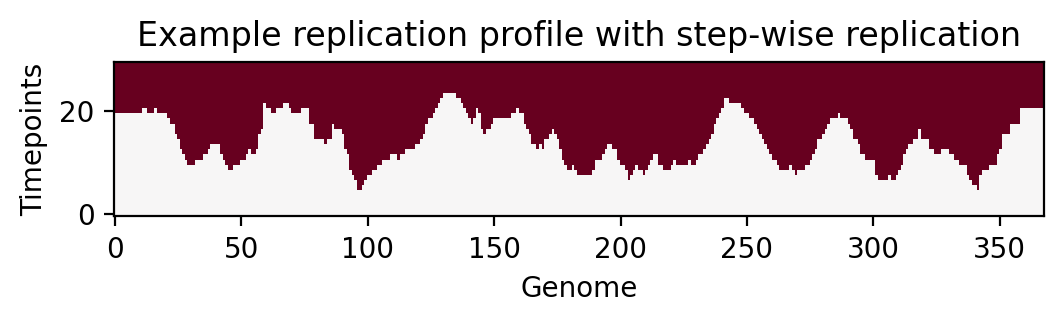

In [5]:
plt.figure(figsize=(6, 1))
plt.imshow(copy_number_matrix.T, origin='lower', aspect='auto', vmin=0, vmax=2, 
          cmap='RdBu_r', interpolation='none')
plt.title("Example replication profile with step-wise replication")
plt.xlabel("Genome")
plt.ylabel("Timepoints")

In [6]:
# Number of origins that have replicated per timepoint
k = (copy_number_matrix > 1).sum(axis=0)
total_copy_number = k*2 + (n-k)
total_copy_number_reshaped = total_copy_number.reshape((1, -1))

normalized_copy_numbers = copy_number_matrix * n / total_copy_number_reshaped

In [7]:
chrom10_replication_profile['genomic_index'] = np.arange(len(chrom10_replication_profile))
replication_sorted_arr_index = chrom10_replication_profile.sort_values('replication_index')['genomic_index']

Text(0.5, 1.0, 'Copy number reconstructed')

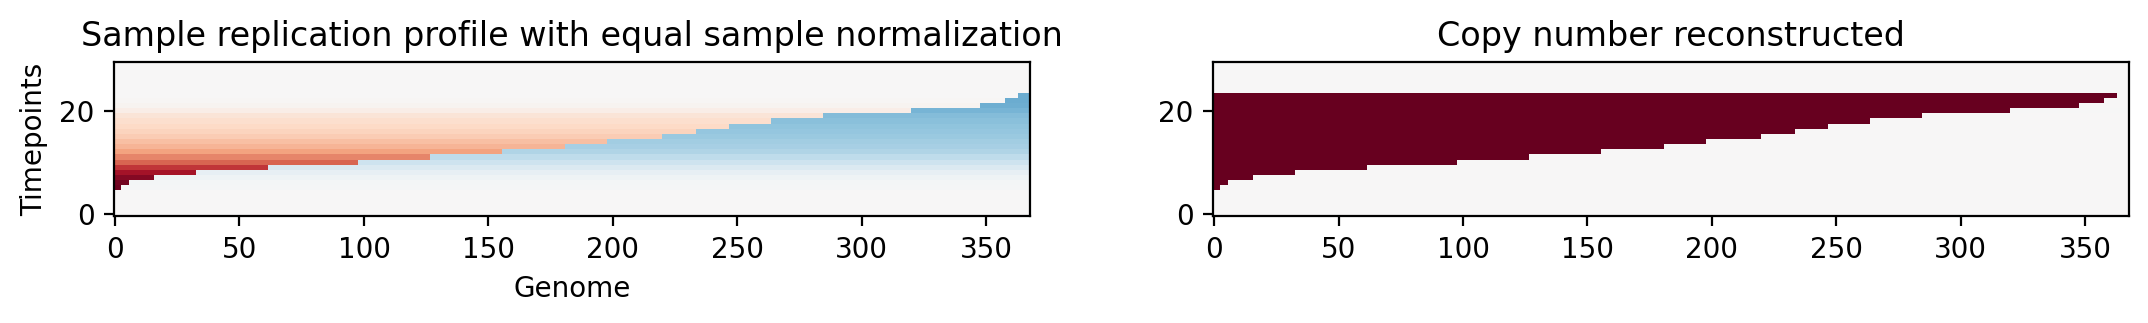

In [8]:
plt.figure(figsize=(13, 1))

sorted_normalized_dat = normalized_copy_numbers.T[:, replication_sorted_arr_index]

plt.subplot(1, 2, 1)
plt.imshow(sorted_normalized_dat, origin='lower', aspect='auto', vmin=0, vmax=2, 
          cmap='RdBu_r', interpolation='none')
plt.title("Sample replication profile with equal sample normalization")
plt.xlabel("Genome")
plt.ylabel("Timepoints")

# Estimate the total copy number from the normalized data by 
# counting up regions greater than 1...
total_copy_number_estimation = ((normalized_copy_numbers > 1)+1).sum(axis=0)
copy_number_reconstructed = normalized_copy_numbers * \
    total_copy_number_estimation.reshape((1, -1)) / n

plt.subplot(1, 2, 2)
plt.imshow(copy_number_reconstructed.T[:, replication_sorted_arr_index], 
           origin='lower', aspect='auto', vmin=0, vmax=2, 
          cmap='RdBu_r', interpolation='none')
plt.title("Copy number reconstructed")

# Reconstsru

Text(0.5, 1.0, 'Total copy curve, C')

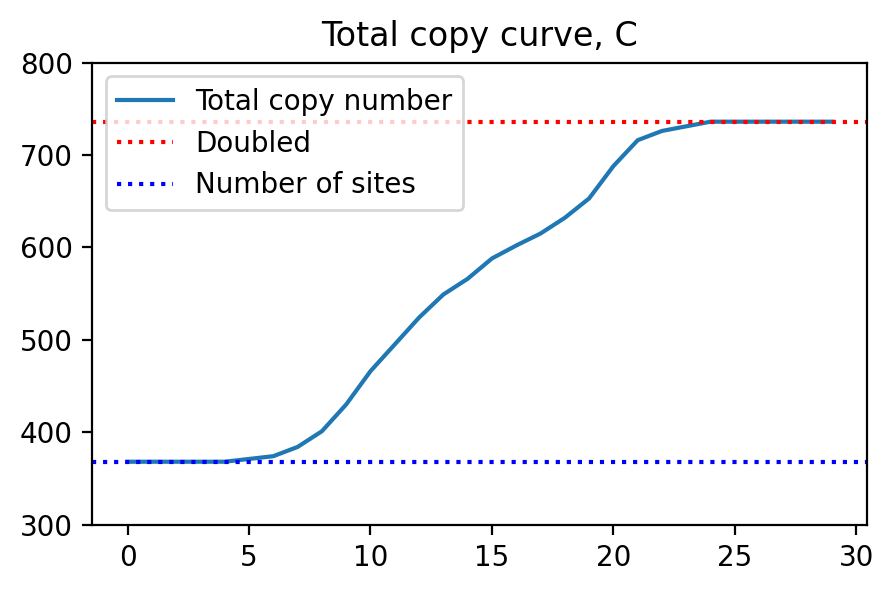

In [9]:
plt.figure(figsize=(5, 3))

total_copies_per_time = copy_number_matrix.sum(axis=0)
plt.plot(total_copies_per_time, label="Total copy number")
plt.axhline(368*2, c='red', label="Doubled", ls='dotted')
plt.axhline(368, c='blue', label="Number of sites", ls='dotted')
plt.legend()
plt.ylim(300, 800)
plt.title("Total copy curve, C")

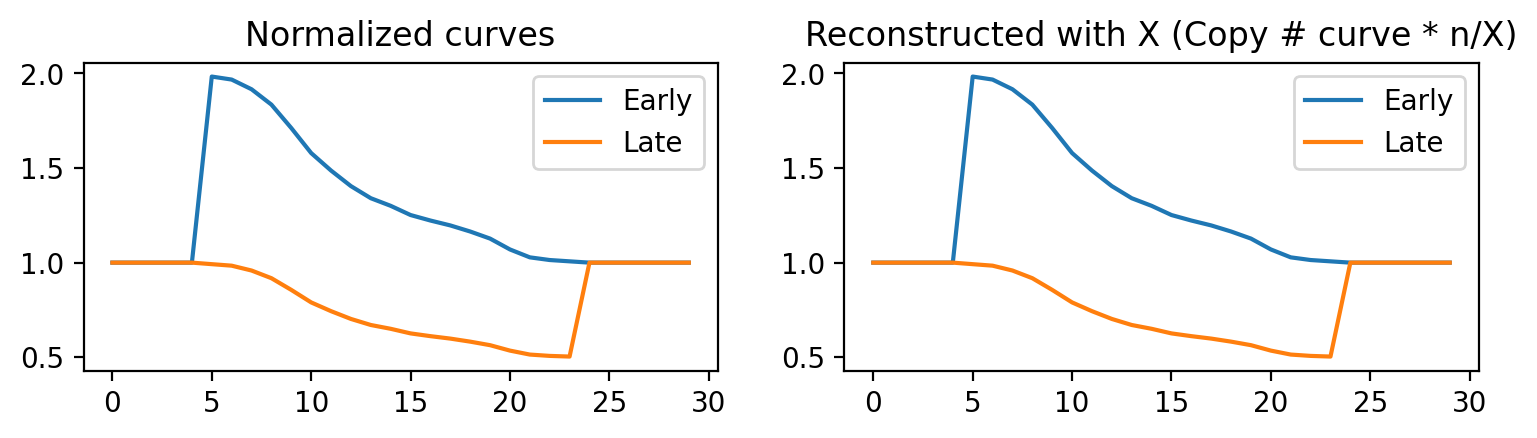

In [10]:
plt.figure(figsize=(9, 2))
plt.subplot(1, 2, 1)
plt.plot(sorted_normalized_dat[:, 0], label='Early')
plt.plot(sorted_normalized_dat[:, -1], label='Late')
plt.legend()
plt.title("Normalized curves")

plt.subplot(1, 2, 2)
true_early_copy_curve = copy_number_matrix[replication_sorted_arr_index][0]
true_late_copy_curve = copy_number_matrix[replication_sorted_arr_index][-1]
plt.plot(true_early_copy_curve * n/total_copies_per_time,
        label="Early")
plt.plot(true_late_copy_curve * n/total_copies_per_time,
       label="Late")
plt.title("Reconstructed with X (Copy # curve * n/X)")
plt.legend()
# Not quite right, there is something going on with the divisor in 
# the subtrahend (subtracting term)


Text(0.5, 1.0, 'Derivation of copy curve, X')

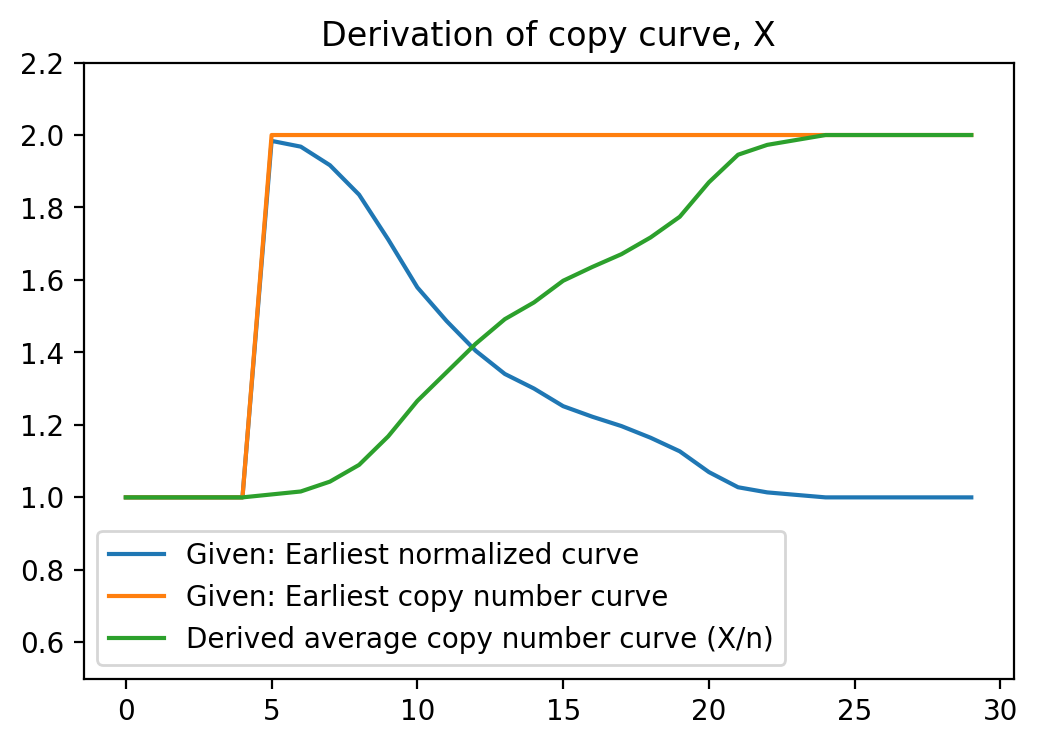

In [11]:
# From the earliest timepoint, can we reconstruct X?

earliest_normalized_curve = sorted_normalized_dat[:, 0]
latest_normalized_curve = sorted_normalized_dat[:, -1]

# We know what the true copy curve looks like for this replicaiton time, so compute
derived_total_copy_curve = 1/(earliest_normalized_curve/true_early_copy_curve/n)

plt.figure(figsize=(6, 4))
plt.plot(earliest_normalized_curve, label="Given: Earliest normalized curve")
plt.plot(true_early_copy_curve, label="Given: Earliest copy number curve")
plt.plot(derived_total_copy_curve/n, label="Derived average copy number curve (X/n)")
plt.legend()
plt.ylim(0.5, 2.2)
plt.title("Derivation of copy curve, X")

Text(0.5, 1.0, 'Copy number reconstructed')

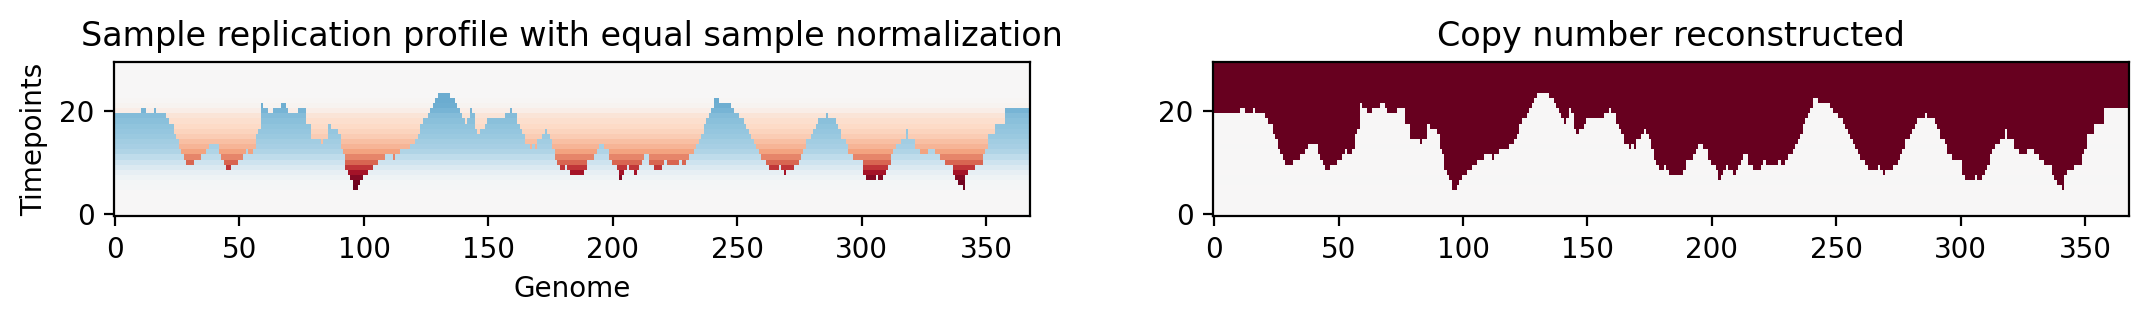

In [12]:
plt.figure(figsize=(13, 1))

plt.subplot(1, 2, 1)
plt.imshow(normalized_copy_numbers.T, origin='lower', aspect='auto', vmin=0, vmax=2, 
          cmap='RdBu_r', interpolation='none')
plt.title("Sample replication profile with equal sample normalization")
plt.xlabel("Genome")
plt.ylabel("Timepoints")

# Estimate the total copy number from the normalized data by 
# counting up regions greater than 1...
copy_number_reconstructed = normalized_copy_numbers * \
    derived_total_copy_curve.reshape((1, -1)) / n

plt.subplot(1, 2, 2)
plt.imshow(copy_number_reconstructed.T, origin='lower', aspect='auto', vmin=0, vmax=2, 
          cmap='RdBu_r', interpolation='none')
plt.title("Copy number reconstructed")

# Reconstsru

In [13]:
# Aside analysis to see what the raw data looks like when sorted by replication timing
# and an ad-hoc measure of replication timing using rank ordering....

In [14]:
normalized_copy_numbers.shape

(368, 30)

Text(0.5, 1.0, 'Simple synchronized H matrix')

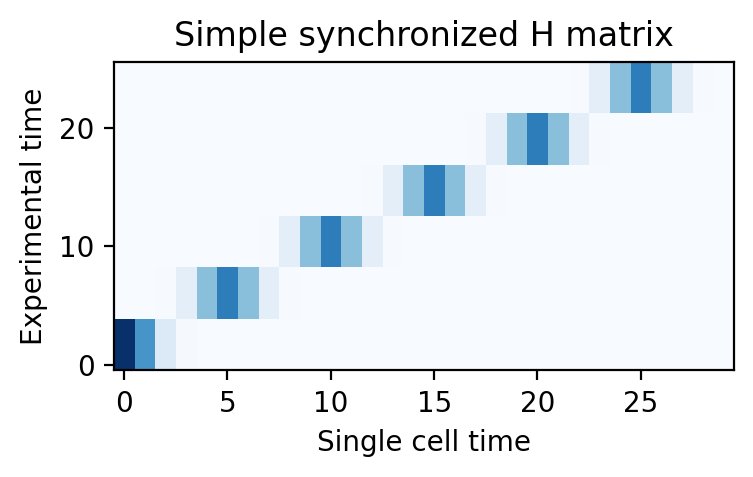

In [15]:
# Create an H with 5 timepoints that converts the above "true" replication timing
# into an "experimental" timecourse.

from scipy.stats.distributions import norm

single_cell_timepoints = np.arange(0, 30, 1)
experimental_timepoints = np.arange(0, 30, 5)

simple_H = np.zeros((len(experimental_timepoints), len(single_cell_timepoints)))

for i, x in enumerate(experimental_timepoints):
    ys = norm.pdf(single_cell_timepoints, x, 1)
    ys = ys/ys.sum()
    simple_H[i, :] = ys

plt.figure(figsize=(4, 2))
plt.imshow(simple_H,
          extent=[single_cell_timepoints[0]-.5, single_cell_timepoints[-1]+.5,
                  experimental_timepoints[0]-.5, experimental_timepoints[-1]+.5],
          aspect='auto', origin='lower', cmap='Blues')
plt.xlabel("Single cell time")
plt.ylabel("Experimental time")
plt.title("Simple synchronized H matrix")


In [16]:
normalized_copy_numbers.T.shape, simple_H.shape

((30, 368), (6, 30))

Text(0.5, 0.98, 'High resolution replication profile to experimental read counts')

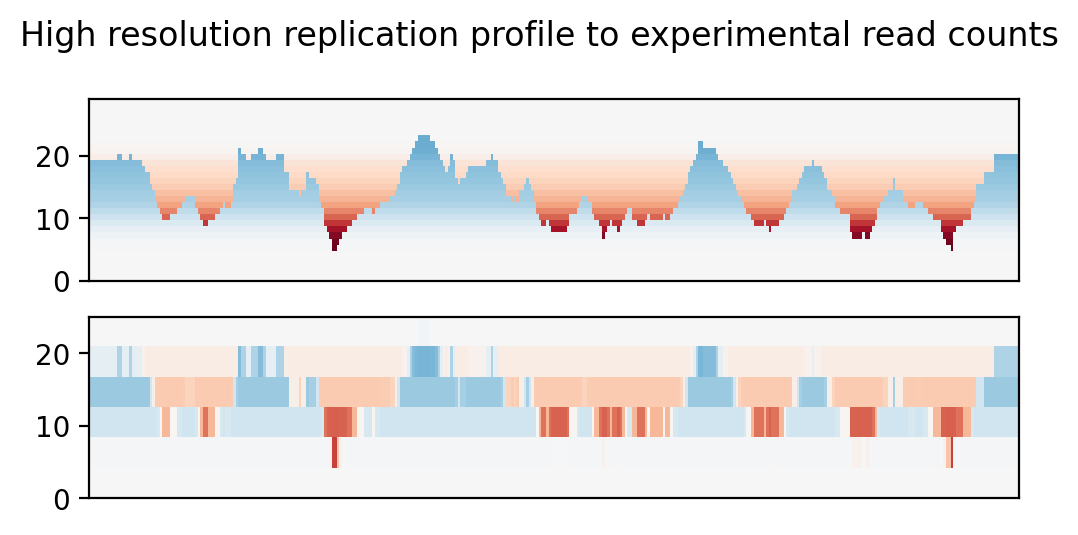

In [17]:
experimental_data_G = simple_H @ normalized_copy_numbers.T

plt.figure(figsize=(6, 4))
plt.subplot(3, 1, 1)
plt.imshow(normalized_copy_numbers.T, vmin=0, vmax=2, cmap='RdBu_r', origin='lower', 
    aspect='auto', interpolation='none', extent=[experimental_data_G.shape[0], experimental_data_G.shape[1],
                                                0, single_cell_timepoints[-1]])
plt.xticks([])

plt.subplot(3, 1, 2)
plt.imshow(experimental_data_G, vmin=0, vmax=2, cmap='RdBu_r', origin='lower', aspect='auto', 
          interpolation='none', extent=[experimental_data_G.shape[0],
                                        experimental_data_G.shape[1],
                                                0, experimental_timepoints[-1]])
plt.xticks([])

# plt.subplot(3, 1, 3)
#reconstructed_F = np.linalg.pinv(simple_H) @ G
#plt.imshow(reconstructed_F, vmin=0, vmax=2, cmap='RdBu_r', origin='lower', 
#    aspect='auto', interpolation='none', extent=[G.shape[0], G.shape[1],
#                                                0, single_cell_timepoints[-1]])

plt.suptitle("High resolution replication profile to experimental read counts")

In [18]:
# Sort by the max to get an approximation of the early to late replication timing
sorted_indices = np.argsort(normalized_copy_numbers.max(axis=1))[::-1]
sorted_indices_G = np.argsort(experimental_data_G.max(axis=0))[::-1]

Text(0.5, 1.0, 'Normalized, G copy numbers')

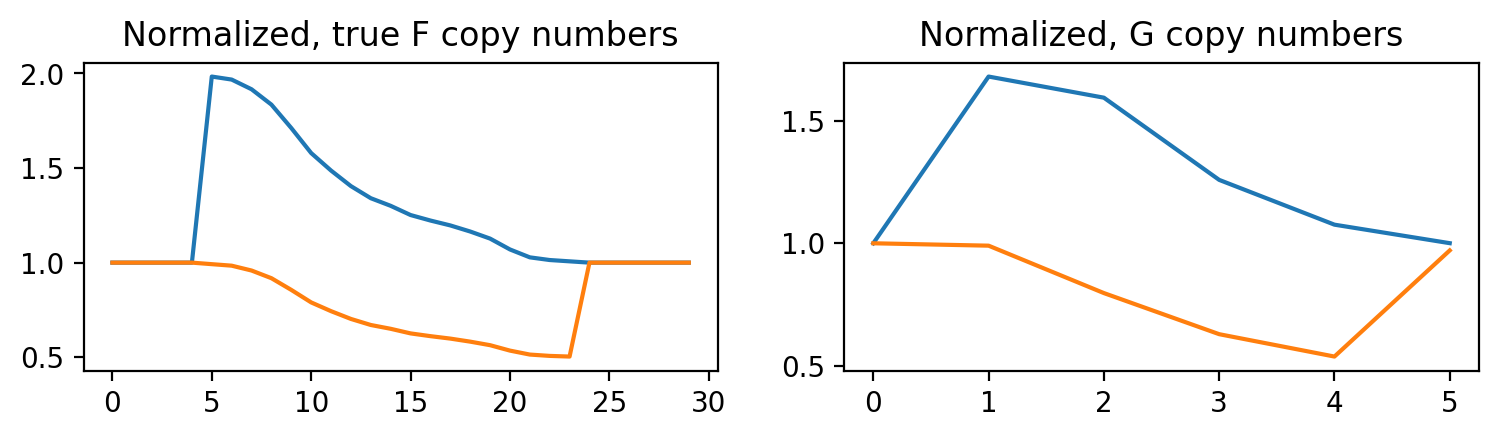

In [19]:
plt.figure(figsize=(9, 2))
plt.subplot(1, 2, 1)

# Here are the earliest and latest timepoints...
plt.plot(normalized_copy_numbers[sorted_indices][0])
plt.plot(normalized_copy_numbers[sorted_indices][-1])
plt.title("Normalized, true F copy numbers")

plt.subplot(1, 2, 2)
# Here are the earliest and latest timepoints...
plt.plot(experimental_data_G[:, sorted_indices_G][:, 0])
plt.plot(experimental_data_G[:, sorted_indices_G][:, -1])
plt.title("Normalized, G copy numbers")


# Idea for deconvolution to find replication timing

Idea: Compute a consensus X curve from a set of early and late replicating regions (or the cleanest set of positions)

Use this fixed curve for the deconvolution of each of the individual sites independently...


Other idea is to use CLOCCS copy number curve as X-predefined....

In [20]:
# Take the early curve and X and attempt to reconstruct....
num_sites = len(normalized_copy_numbers)

indices = np.arange(0, experimental_data_G.shape[1])

# Here are the earliest and latest timepoints...
F = normalized_copy_numbers[indices]
G = experimental_data_G[:, :][:, indices]

H = simple_H

avg_copies_per_time = total_copies_per_time/num_sites

# True F
true_F = copy_number_matrix[sorted_indices][indices]

F.shape, G.shape, total_copies_per_time.shape

((368, 30), (6, 368), (30,))

In [21]:
from src.ToyReplication import ReplicationDeconvolution

replication_solver = ReplicationDeconvolution(true_F, H, G, avg_copies_per_time)

In [22]:
replication_solver.deconvolve()

0/368 - 00:00:00.000
50/368 - 00:00:02.436
100/368 - 00:00:04.808
150/368 - 00:00:07.134
200/368 - 00:00:09.368
250/368 - 00:00:11.697
300/368 - 00:00:14.030
350/368 - 00:00:16.349


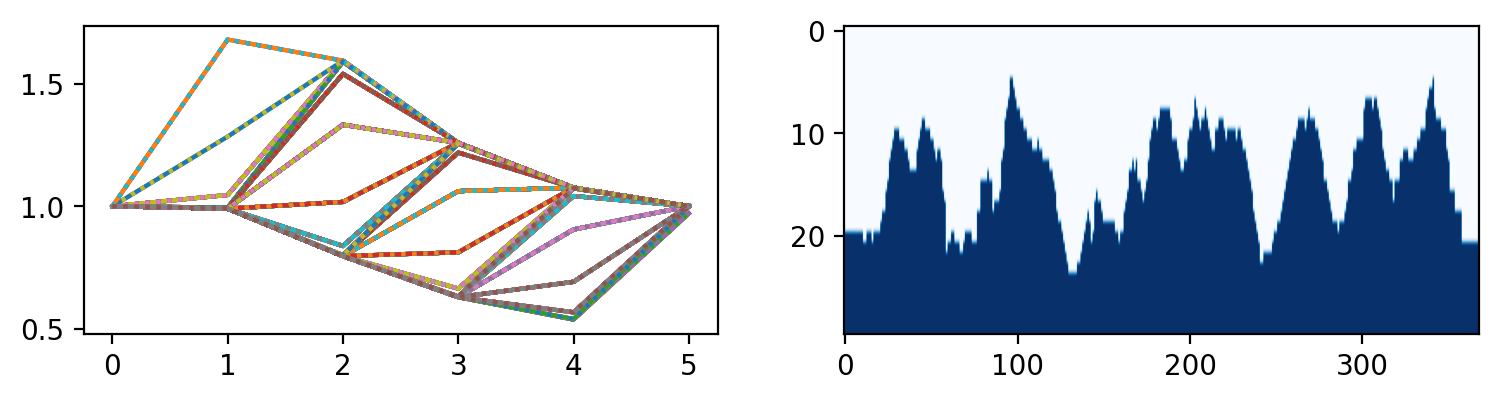

In [23]:
replication_solver.plot_result()

In [24]:
earliest_normalized_curve.reshape((-1, 1)).shape, H.shape
early_G = H @ earliest_normalized_curve
late_G = H @ latest_normalized_curve

In [25]:
from src.ToyReplication import AverageCopyNumberDeconvolution

avg_copy_solver = AverageCopyNumberDeconvolution(H)

In [26]:
avg_copy_solver.deconvolve(late_G)

In [27]:
# Iterate through all of the G indices and retrieve all of the estimated avg copy
# number curves, they won't agree, but hopefully the average across them will be close to the
# ground truth

from src.timer import Timer

timer = Timer()

n, m = H.shape
n, num_sites = experimental_data_G.shape

genomic_f_solutions = np.zeros((num_sites, m))
average_copy_curve_solutions = np.zeros((num_sites, m))
replication_indices = np.zeros(num_sites)

for genomic_index in range(num_sites):
    current_g = experimental_data_G[:, genomic_index]

    avg_copy_solver.deconvolve(current_g)
    genomic_f_solutions[genomic_index] = avg_copy_solver.f_solution
    average_copy_curve_solutions[genomic_index] = avg_copy_solver.avg_curve_solution
    replication_indices = avg_copy_solver.min_sol_idx
    
    if genomic_index % 20 == 0:
        timer.print_time(f"{genomic_index}/{num_sites}")


0/368 - 00:00:01.000
20/368 - 00:00:19.963
40/368 - 00:00:39.464
60/368 - 00:00:59.067
80/368 - 00:01:18.742
100/368 - 00:01:37.945
120/368 - 00:01:56.662
140/368 - 00:02:15.855
160/368 - 00:02:35.578
180/368 - 00:02:54.161
200/368 - 00:03:12.433
220/368 - 00:03:30.519
240/368 - 00:03:48.459
260/368 - 00:04:06.380
280/368 - 00:04:24.605
300/368 - 00:04:43.593
320/368 - 00:05:03.353
340/368 - 00:05:23.516
360/368 - 00:05:42.885


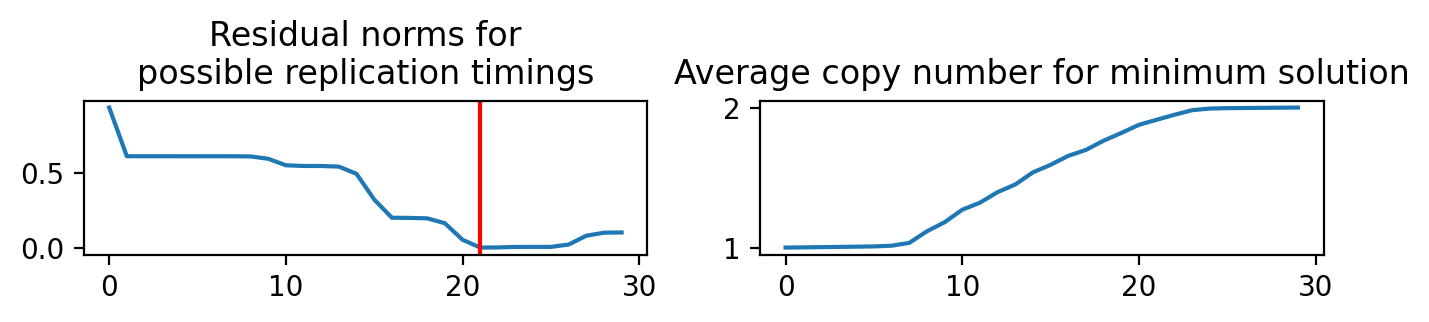

In [28]:
avg_copy_solver.plot_rn_curve()

Text(0.5, 1.0, 'All computed avg copy curves')

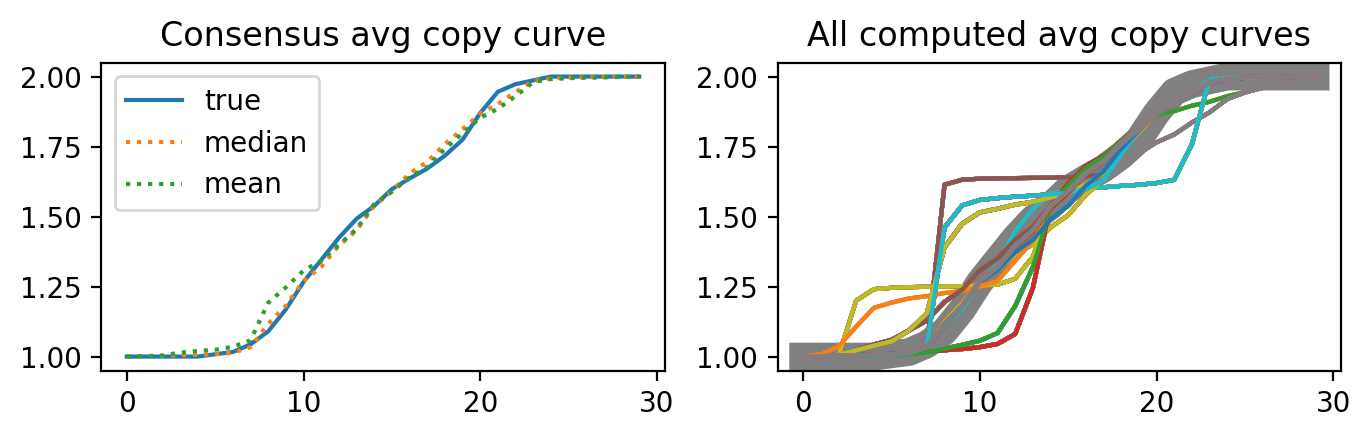

In [29]:
median_deconv_avg_copy_num = np.quantile(1/average_copy_curve_solutions.T, q=0.5, axis=1)
mean_deconv_avg_copy_num = np.mean(1/average_copy_curve_solutions.T, axis=1)

plt.figure(figsize=(8, 2))
plt.subplot(1, 2, 1)
plt.plot(avg_copies_per_time, label='true')
plt.plot(median_deconv_avg_copy_num, ls='dotted', label='median')
plt.plot(mean_deconv_avg_copy_num, ls='dotted', label='mean')
plt.legend()
plt.title("Consensus avg copy curve")

plt.subplot(1, 2, 2)
plt.plot(avg_copies_per_time, label='true', lw=10, c='gray', zorder=0)
plt.plot(1/average_copy_curve_solutions.T, zorder=1)
plt.title("All computed avg copy curves")


Text(0.5, 1.0, 'Predicted solution, individual average copy curves')

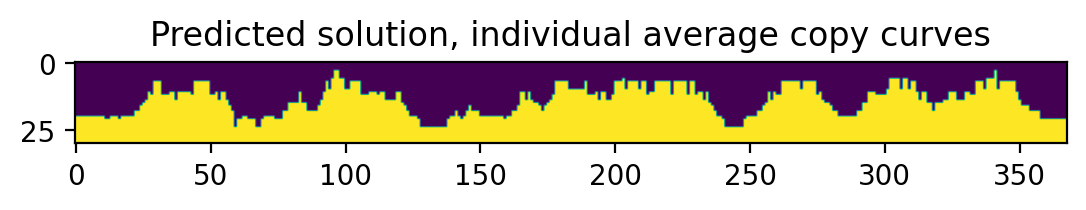

In [30]:
plt.imshow(genomic_f_solutions.T)
plt.title("Predicted solution, individual average copy curves")

In [31]:
from src.ToyReplication import ReplicationDeconvolution

est_copy_num_replication_solver = ReplicationDeconvolution(true_F, H, G, mean_deconv_avg_copy_num)
est_copy_num_replication_solver.deconvolve()

0/368 - 00:00:00.000
50/368 - 00:00:02.334
100/368 - 00:00:04.677
150/368 - 00:00:07.018
200/368 - 00:00:09.266
250/368 - 00:00:11.603
300/368 - 00:00:13.930
350/368 - 00:00:16.199


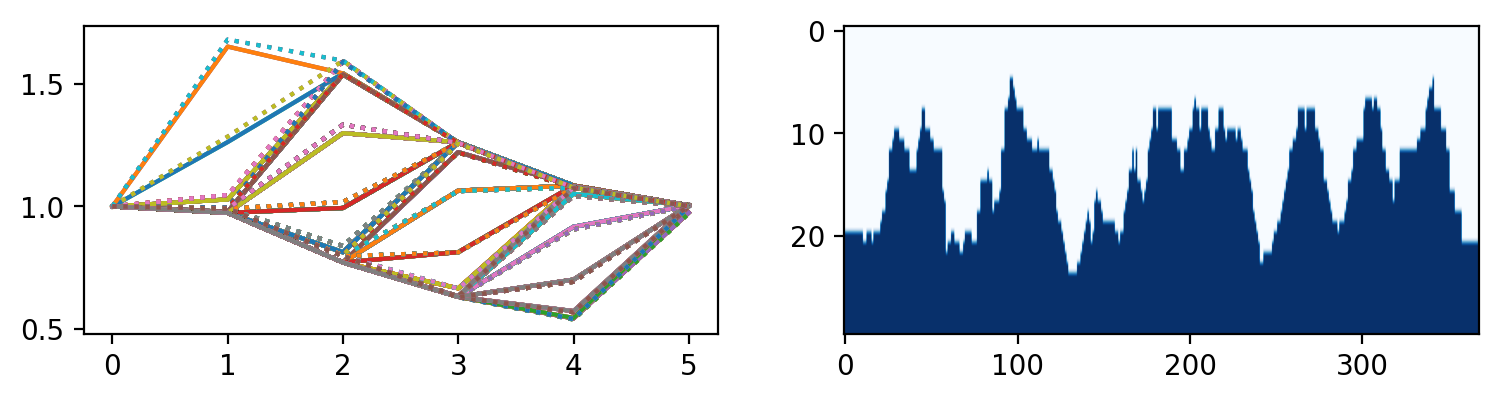

In [32]:
est_copy_num_replication_solver.plot_result()

([], [])

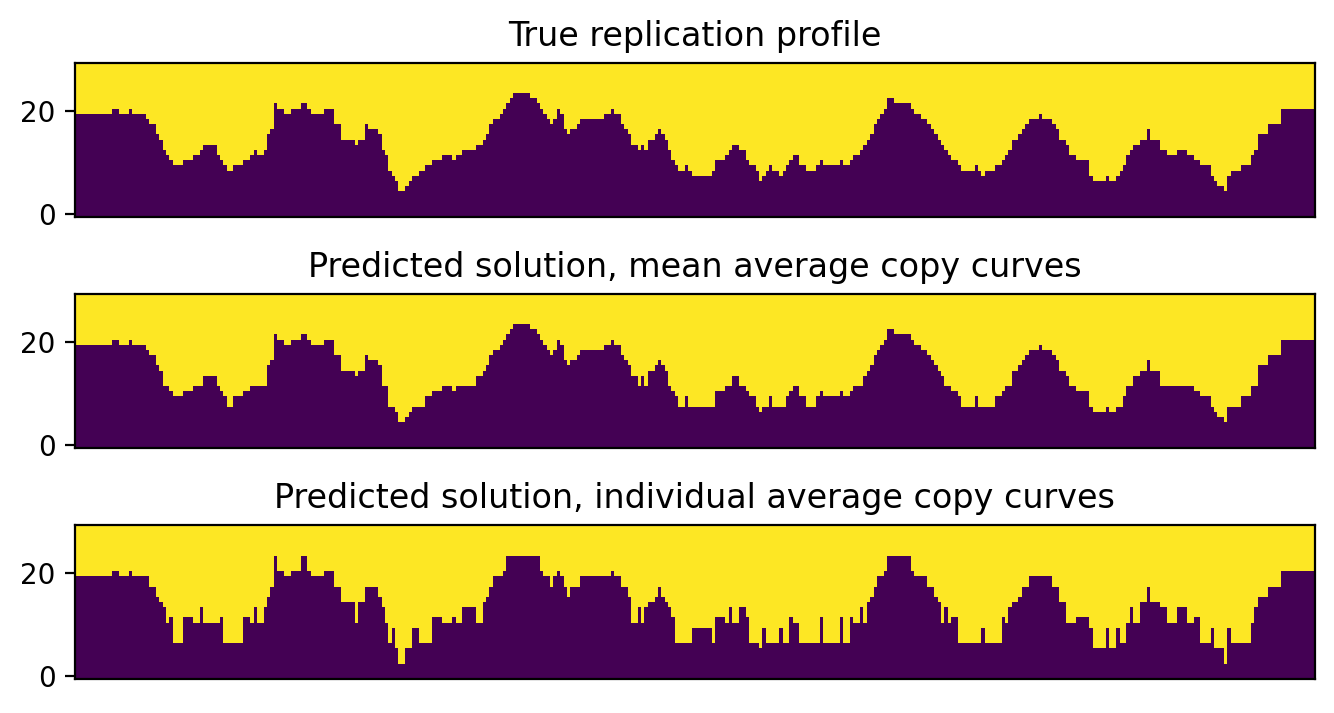

In [33]:
plt.figure(figsize=(8, 4))

plt.subplot(3, 1, 1)
plt.imshow(copy_number_reconstructed.T, origin='lower', aspect='auto', vmin=1, vmax=2,
          cmap='viridis', interpolation='none')
plt.title("True replication profile")
plt.xticks([])

plt.subplot(3, 1, 2)
plt.imshow(est_copy_num_replication_solver.F, origin='lower', aspect='auto', vmin=0, vmax=1,
          cmap='viridis', interpolation='none')
plt.title("Predicted solution, mean average copy curves")
plt.xticks([])

plt.subplot(3, 1, 3)
plt.imshow(genomic_f_solutions.T, origin='lower', aspect='auto', vmin=1, vmax=2,
          cmap='viridis', interpolation='none')
plt.title("Predicted solution, individual average copy curves")

plt.subplots_adjust(hspace=0.5)
plt.xticks([])

### Success in mixed simulated replication timing deconvolution.
Wednesday, December 4, 2024

1. Identified proper deconvolution of raw mixture data population:
   - Raw mixed data -> Estimated as H*F
   - Where F is the copy number, normalized by time (equal samples)
   - F is converted into unnormalized-raw copy number using X (the overall growth in copy number per time).
2. When X is known, the deconvolution is trivial and a proper replication curve is found.
3. When X is not known, it is estimated through individual genomic location estimations.
   - This estimation varies from location to location due to estimation errors.
   - Thus, in the toy example, we estimate X for all genomic locations. Then compute an average of these estimated X's.
4. Then, run the deconvolution to estimate F for all genomic locations to compute a replication timing.
   

(16, 178)

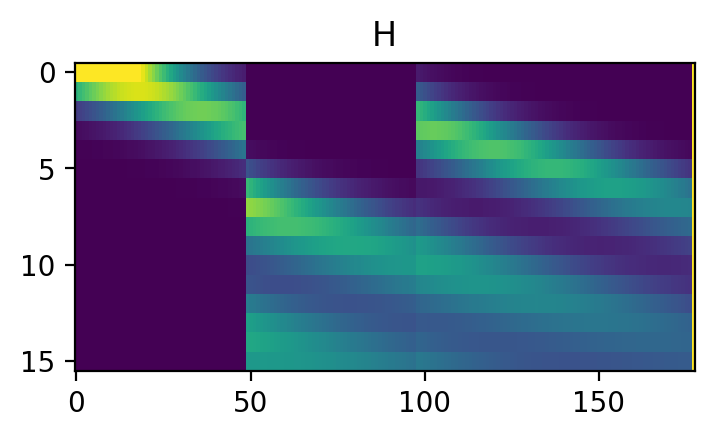

In [1398]:
from src.single_G1_config import load_yl_replicate1_rg1_alpha_vst_config

# Load the config for replicate 1
config = load_yl_replicate1_rg1_alpha_vst_config(longer_file=True)
H, _ = config.calcH_function(config.intervals_wt1, config.WT1_TIMEPOINTS)
plt.figure(figsize=(4, 2))
plt.imshow(H, vmax=0.02, aspect='auto')
plt.title("H")
H.shape

In [140]:
# Let's take a replication profile and convert it into the equal sample example...
path = 'data/replication_timing/yl_2019/chrom_replication_timing_shared.csv'
chrom_repl_profile = pd.read_csv(path).set_index(['chr', 'start'])
chrom10_replication_profile = chrom_repl_profile.loc[10]

chrom10_replication_profile.sort_values('replication_index')

chr10_replication_copy_mat = np.ones((H.shape[1], len(chrom10_replication_profile)))
for i in range(len(chrom10_replication_profile)):
    repl_idx = chrom10_replication_profile.iloc[i].replication_index
    chr10_replication_copy_mat[repl_idx:-1, i] = 2


In [141]:
# Number of origins that have replicated per timepoint
n = len(chrom10_replication_profile)
k = (chr10_replication_copy_mat > 1).sum(axis=1)
total_copy_number = k*2 + (n-k)
total_copy_number_reshaped = total_copy_number.reshape((1, -1))

normalized_chr10_copy_numbers = (chr10_replication_copy_mat * n / \
                                 total_copy_number_reshaped.T)


In [ ]:
from src.RealDataReplication import RealDataReplicationDeconvolution

real_deconv = RealDataReplicationDeconvolution()
genomic_sums = real_deconv.normalized_occupancy.sum(axis=1)

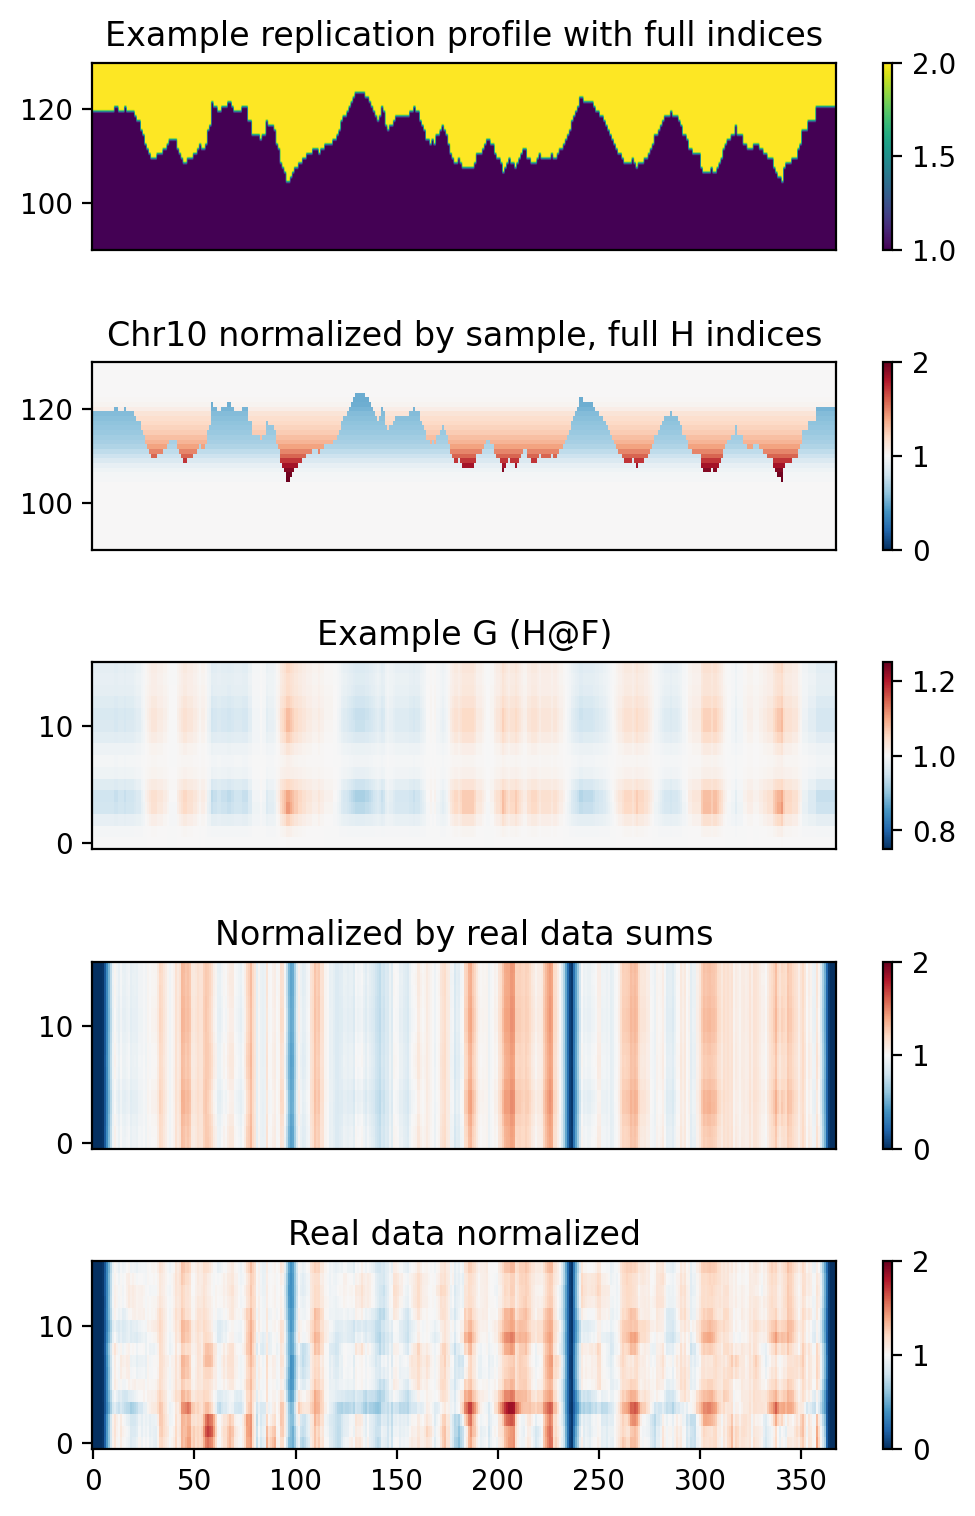

In [315]:
plt.figure(figsize=(6, 9))

plt.subplot(5, 1, 1)
plt.imshow(chr10_replication_copy_mat, origin='lower', aspect='auto')
plt.colorbar()
plt.title("Example replication profile with full indices")
plt.xticks([])
plt.ylim(90, 130)

plt.subplot(5, 1, 2)
plt.imshow(normalized_chr10_copy_numbers, vmin=0, vmax=2, 
           cmap='RdBu_r', origin='lower',  aspect='auto', interpolation='none')
plt.xticks([])
plt.title("Chr10 normalized by sample, full H indices")
plt.ylim(90, 130)
plt.colorbar()
experimental_full_G = H @ normalized_chr10_copy_numbers

plt.subplot(5, 1, 3)
plt.imshow(experimental_full_G[:, ], vmin=0.75, vmax=1.25, cmap='RdBu_r', 
    origin='lower', aspect='auto', interpolation='none')
plt.subplots_adjust(hspace=0.6)
plt.title("Example G (H@F)")
plt.xticks([])
plt.colorbar()

plt.subplot(5, 1, 4)

normalized_by_real_sums = experimental_full_G *\
    genomic_sums.values.reshape((1, -1))/experimental_full_G.shape[0]

plt.imshow(normalized_by_real_sums, vmin=0, vmax=2, cmap='RdBu_r', 
    origin='lower', aspect='auto', interpolation='none')
plt.title("Normalized by real data sums")
plt.xticks([])
plt.colorbar()

real_dat_normalized = real_deconv.normalized_occupancy.T

plt.subplot(5, 1, 5)
plt.imshow(real_dat_normalized, vmin=0, vmax=2, cmap='RdBu_r', 
    origin='lower', aspect='auto', interpolation='none')
plt.title("Real data normalized")
plt.colorbar()

### Observations:
1. The dynamic range is much greater in the raw data.
2. And the replication timing is consistently later in the estimation.
   - Possible explanation: Replication occurs earlier than the predicted S


### Possible explanations for (1):
1. There is additional explanation for the variation in the copy number effects than
   just a doubling of copy number
2. There is an assumption about the copy number counting that I have missed in my 
   normalization scheme.
3. The H matrix variation is too wide


### Current status
Proceed, with known limitations, with opportunity for discussion. Should not make changes to H at this point. If (1 or 2), it is not clear at the moment. And correction will end up having a much smaller on the raw data.


### Attempt 1: Min Max Normalization

If we assume each column has an effect in which copy number is not strictly doubled, we can model and scale each column by the raw data's max min. 

This kind of blows out the equal sample normalization a bit. But not too much as we can still determine the replication timing by scaling the raw g curve to a fixed min max range.

The assumption/caveat here must be clearly stated: that the multiplicative error of the MNase-seq data, makes it difficult to model the doubling of reads exact. And this is a genome-wide effect in which locus reads are increase much greater than can be accounted for strictly from copy number doubling and equal sample normalization...

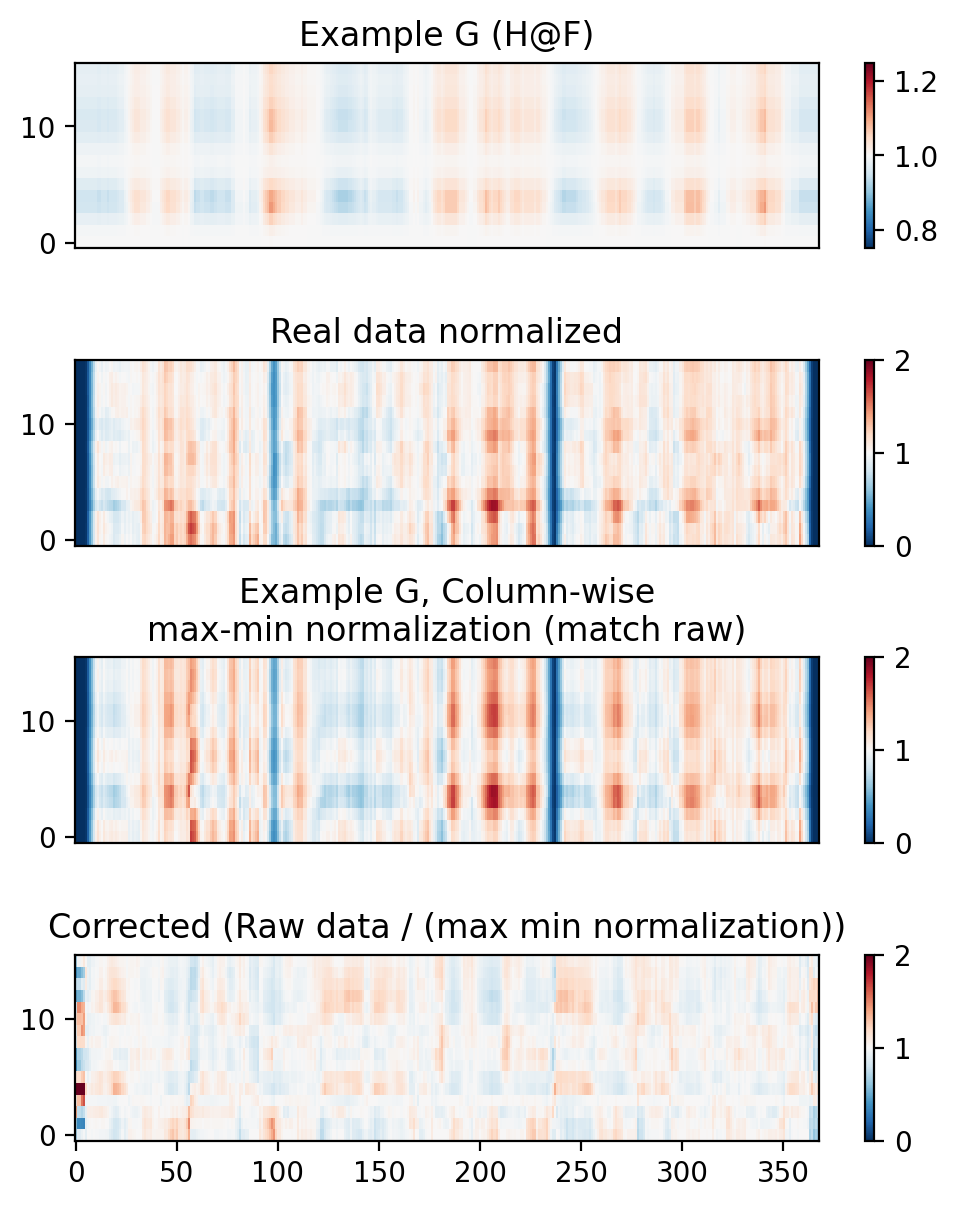

In [343]:
# Try scaling each column of the predicted G by the min maxes of each column. It should
# look closer to the real data...

predicted_column_mins = experimental_full_G.min(axis=0).reshape((1, -1))
predicted_column_maxs = experimental_full_G.max(axis=0).reshape((1, -1))

real_column_mins = real_dat_normalized.min(axis=0).values.reshape((1, -1))
real_column_maxs = real_dat_normalized.max(axis=0).values.reshape((1, -1))

exp_translated = (experimental_full_G - predicted_column_mins)
exp_scaled = exp_translated/(predicted_column_maxs - predicted_column_mins)

real_scaled_up = exp_scaled*(real_column_maxs-real_column_mins)
experimental_G_scaled_by_min_max = real_scaled_up+real_column_mins

corrected_dat = real_dat_normalized / experimental_G_scaled_by_min_max

plt.figure(figsize=(6, 7))
plt.subplot(4, 1, 1)
plt.imshow(experimental_full_G[:, ], vmin=0.75, vmax=1.25, cmap='RdBu_r', 
    origin='lower', aspect='auto', interpolation='none')
plt.subplots_adjust(hspace=0.6)
plt.title("Example G (H@F)")
plt.xticks([])
plt.colorbar()

plt.subplot(4, 1, 2)
plt.imshow(real_dat_normalized, vmin=0, vmax=2, cmap='RdBu_r', 
    origin='lower', aspect='auto', interpolation='none')
plt.title("Real data normalized")
plt.colorbar()
plt.xticks([])

plt.subplot(4, 1, 3)
plt.imshow(experimental_G_scaled_by_min_max, vmin=0, vmax=2, cmap='RdBu_r', 
    origin='lower', aspect='auto', interpolation='none')
plt.colorbar()
plt.xticks([])
plt.title("Example G, Column-wise\nmax-min normalization (match raw)")

plt.subplot(4, 1, 4)
plt.imshow(corrected_dat, 
           vmin=0, vmax=2, cmap='RdBu_r', 
    origin='lower', aspect='auto', interpolation='none')
plt.colorbar()
plt.title("Corrected (Raw data / (max min normalization))")

plt.subplots_adjust(hspace=0.6)

**Normalization**
Thus, after min max normalization, the heatmaps look more similar.

**Correction**
Then, correction is done by dividing the raw data by the min max normalization curves. The results are somewhat satisfactory, where there is disagreement, there may be an increase in reads. The reads in general are less dark red and blue.

# Normalization via Negative Binomial Transformation

December 6, 2024, 11am

Current workflow to deconvolve the replication timing.

1. Transform raw data counts using the negative binomial transformation
2. Estimate the average copy number curve using a first-pass sweep of a subsample of sites. This is a deconvolution of the curve, where the replication time sweeped over all possible values. The rn with the lowest curve is the selected copy curve.
3. Deconvolve the replication timings using this estimation of the copy curve.

In [1819]:
from src.single_G1_config import load_yl_replicate1_rg1_alpha_vst_config
from src.config import load_configs_by_config_type

config1, config2 = load_configs_by_config_type('shared')
config1.calculate_H()
config2.calculate_H()
0

0

In [1821]:
from src.RealDataReplication import RealDataReplicationDeconvolution

real_deconv1 = RealDataReplicationDeconvolution()

In [1823]:
real_deconv1.setup_deconvolution(config1)

In [1832]:
real_deconv1.estimate_rough_average_copy_curve_fit()

0/368 - 00:00:01.564
60/368 - 00:00:07.489
120/368 - 00:00:13.560
180/368 - 00:00:20.097
240/368 - 00:00:28.390
300/368 - 00:00:34.265
360/368 - 00:00:40.178


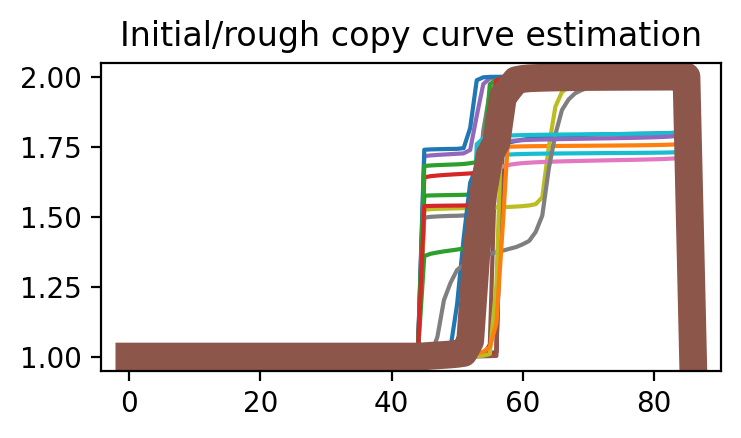

In [1841]:
real_deconv1.plot_rough_copy_curve_estimation()

In [1834]:
real_deconv1.deconvolve()

0/368 - 00:00:00.000
50/368 - 00:00:05.432
100/368 - 00:00:11.380
150/368 - 00:00:18.445
200/368 - 00:00:24.001
250/368 - 00:00:29.770
300/368 - 00:00:35.207
350/368 - 00:00:41.218


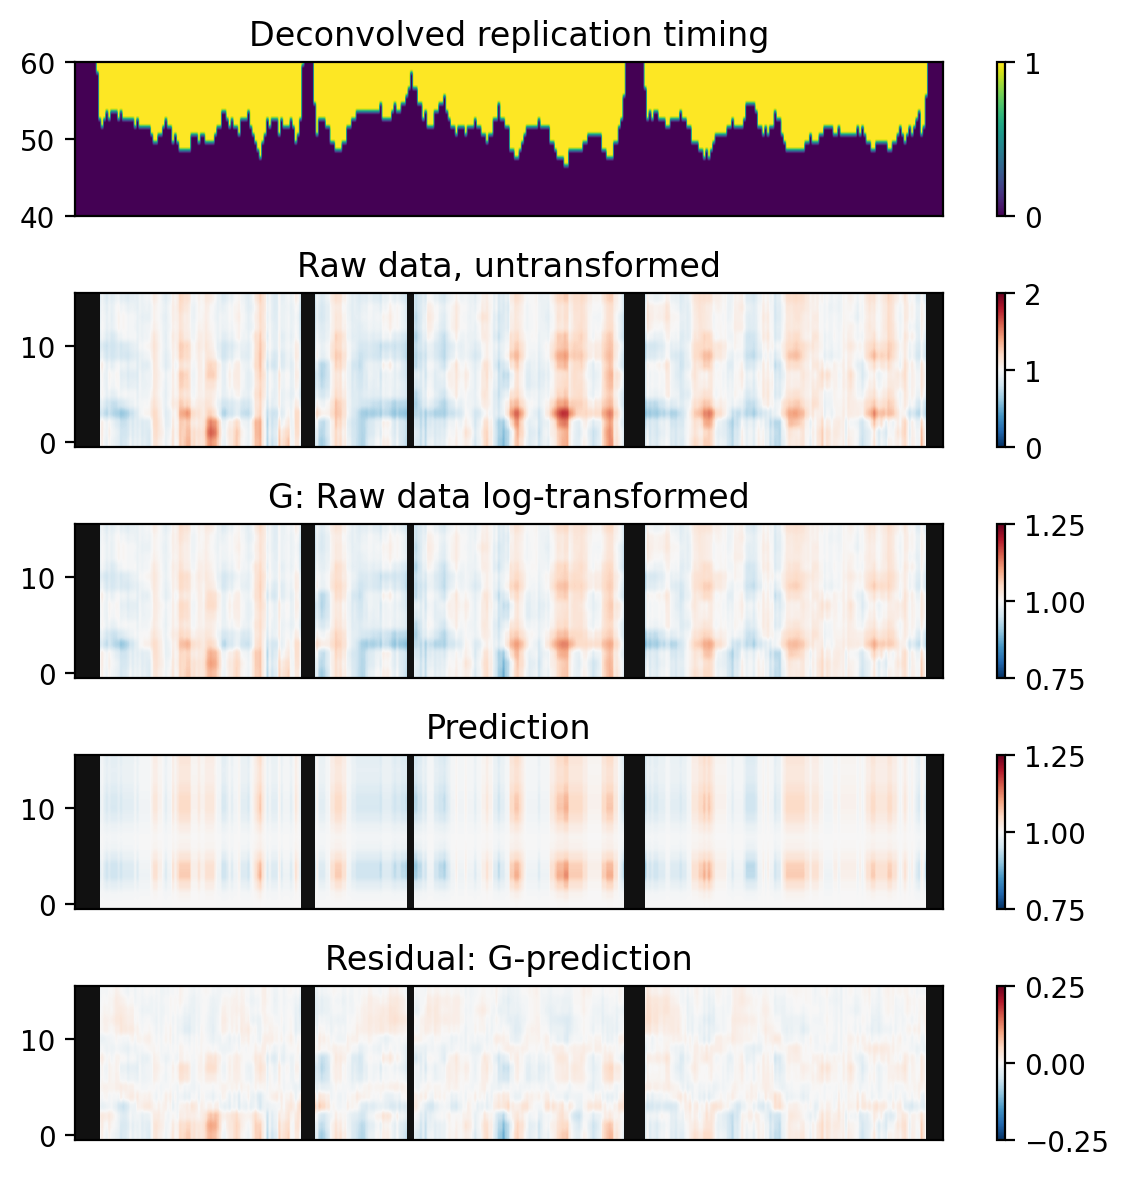

In [1835]:
real_deconv1.plot_deconvolution_prediction()

Modifying the mu0 does not have the effect I would have expected. Shorter mu0's end up causing the model to estimate replication time prior to S-phase, into G1 (therefore truncated).

Path forward is unclear for this train of thought.

# Deconvolution of replicate 2
Next, will deconvolve the second replicate and then merge the deconvolutions to deconvolve the replication profile for the combined data.


In [1847]:
real_deconv2 = RealDataReplicationDeconvolution(config2, replicate=2, chr=10)

In [1850]:
real_deconv2.estimate_rough_average_copy_curve_fit()

0/368 - 00:00:01.763
60/368 - 00:00:10.644
120/368 - 00:00:17.378
180/368 - 00:00:24.044
240/368 - 00:00:30.708
300/368 - 00:00:39.112
360/368 - 00:00:45.679


In [ ]:
real_deconv2.rough_average_copy_curve

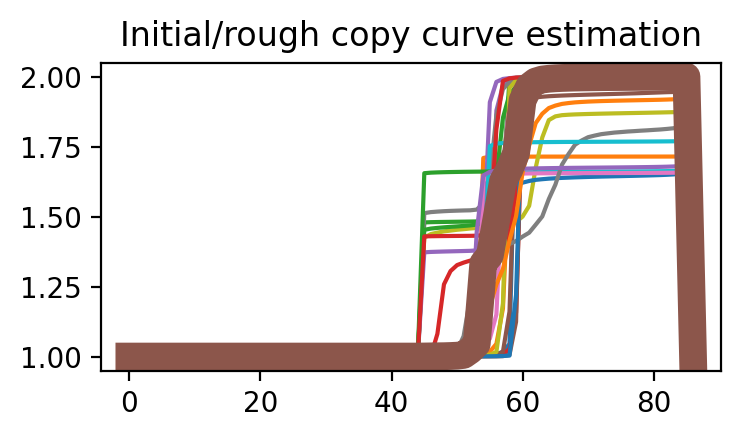

In [1851]:
real_deconv2.plot_rough_copy_curve_estimation()

In [1852]:
real_deconv2.deconvolve()

0/368 - 00:00:00.000
50/368 - 00:00:05.758
100/368 - 00:00:11.788
150/368 - 00:00:19.263
200/368 - 00:00:25.185
250/368 - 00:00:30.994
300/368 - 00:00:36.602
350/368 - 00:00:42.666


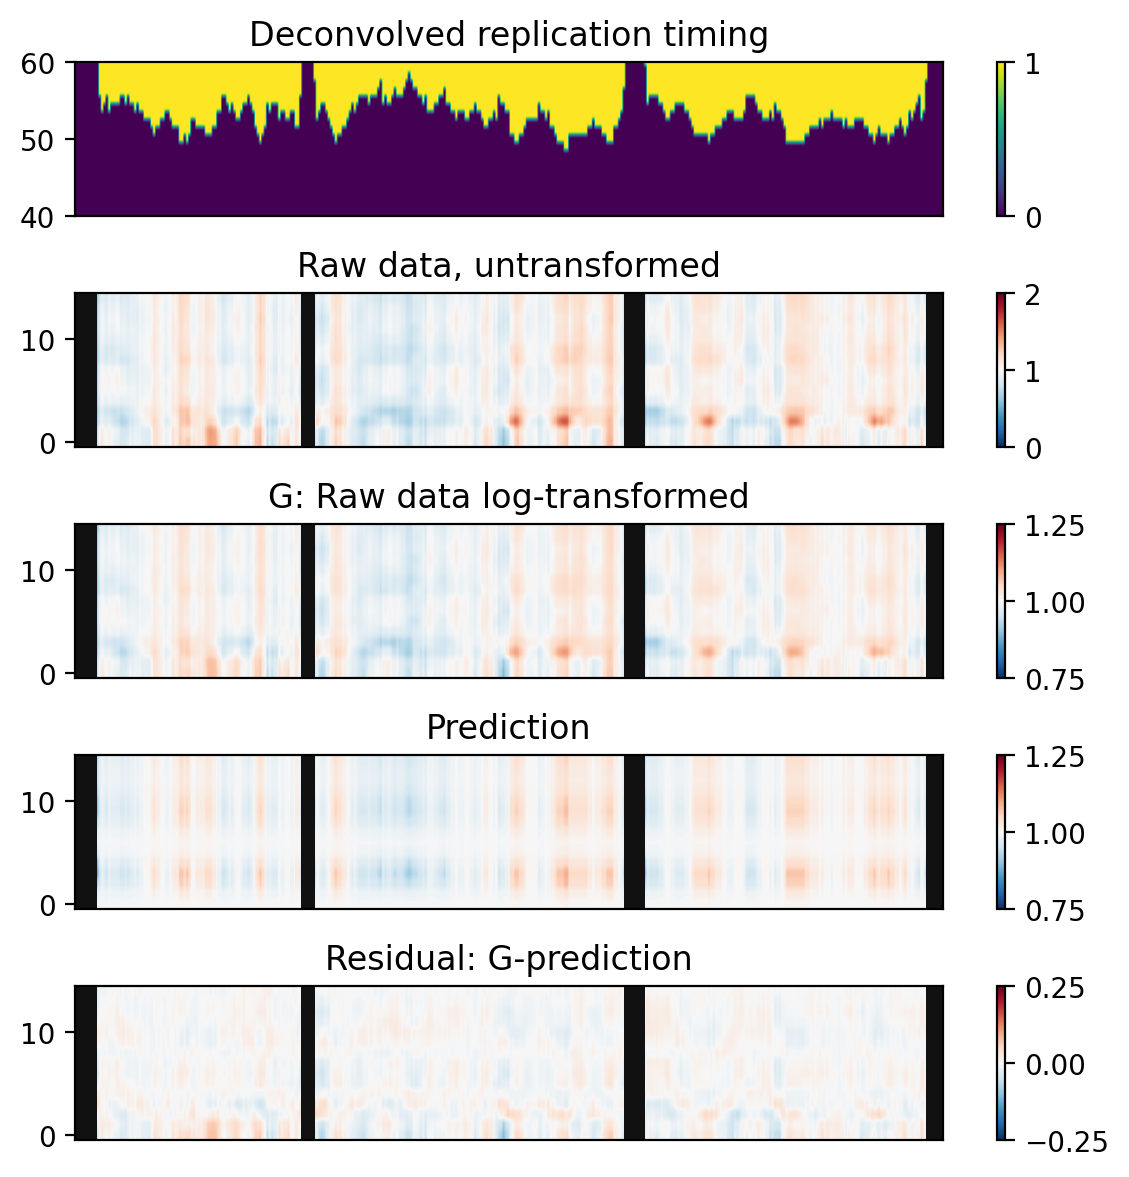

In [1853]:
real_deconv2.plot_deconvolution_prediction()

# Deconvolve combined replication data

1. Modify loading data to create a single G from each replicate
2. Create an H for each of the replicates and combine
3. Deconvolve the average curve and plot
4. Deconvolve the replication profile and plot the predictions



In [1884]:
combined_deconv = RealDataReplicationDeconvolution(chr=10, configs=[config1, config2],
    deconvolve_combined=True)


In [1885]:
combined_deconv.estimate_rough_average_copy_curve_fit()


0/368 - 00:00:04.070
20/368 - 00:00:07.369
40/368 - 00:00:10.634
60/368 - 00:00:13.918
80/368 - 00:00:17.201
100/368 - 00:00:20.441
120/368 - 00:00:23.686
140/368 - 00:00:26.935
160/368 - 00:00:31.957
180/368 - 00:00:35.194
200/368 - 00:00:38.676
220/368 - 00:00:42.285
240/368 - 00:00:45.872
260/368 - 00:00:49.259
280/368 - 00:00:52.674
300/368 - 00:00:56.429
320/368 - 00:01:00.180
340/368 - 00:01:06.028
360/368 - 00:01:09.602


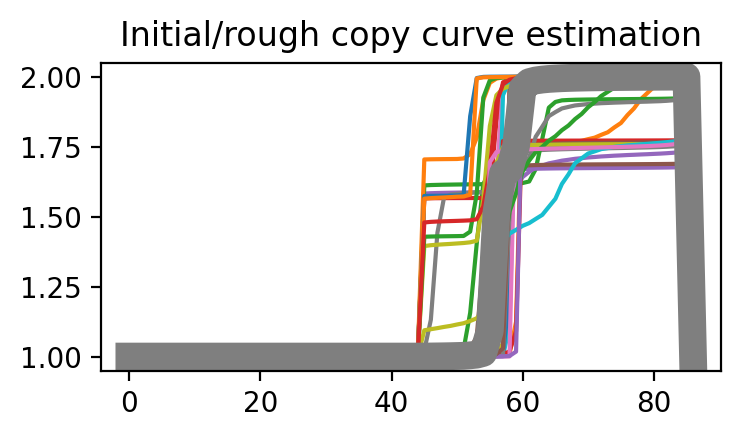

In [1886]:
combined_deconv.plot_rough_copy_curve_estimation()

In [1887]:
combined_deconv.deconvolve()

0/368 - 00:00:00.000
50/368 - 00:00:08.015
100/368 - 00:00:16.603
150/368 - 00:00:24.173
200/368 - 00:00:34.395
250/368 - 00:00:42.518
300/368 - 00:00:50.514
350/368 - 00:00:59.096


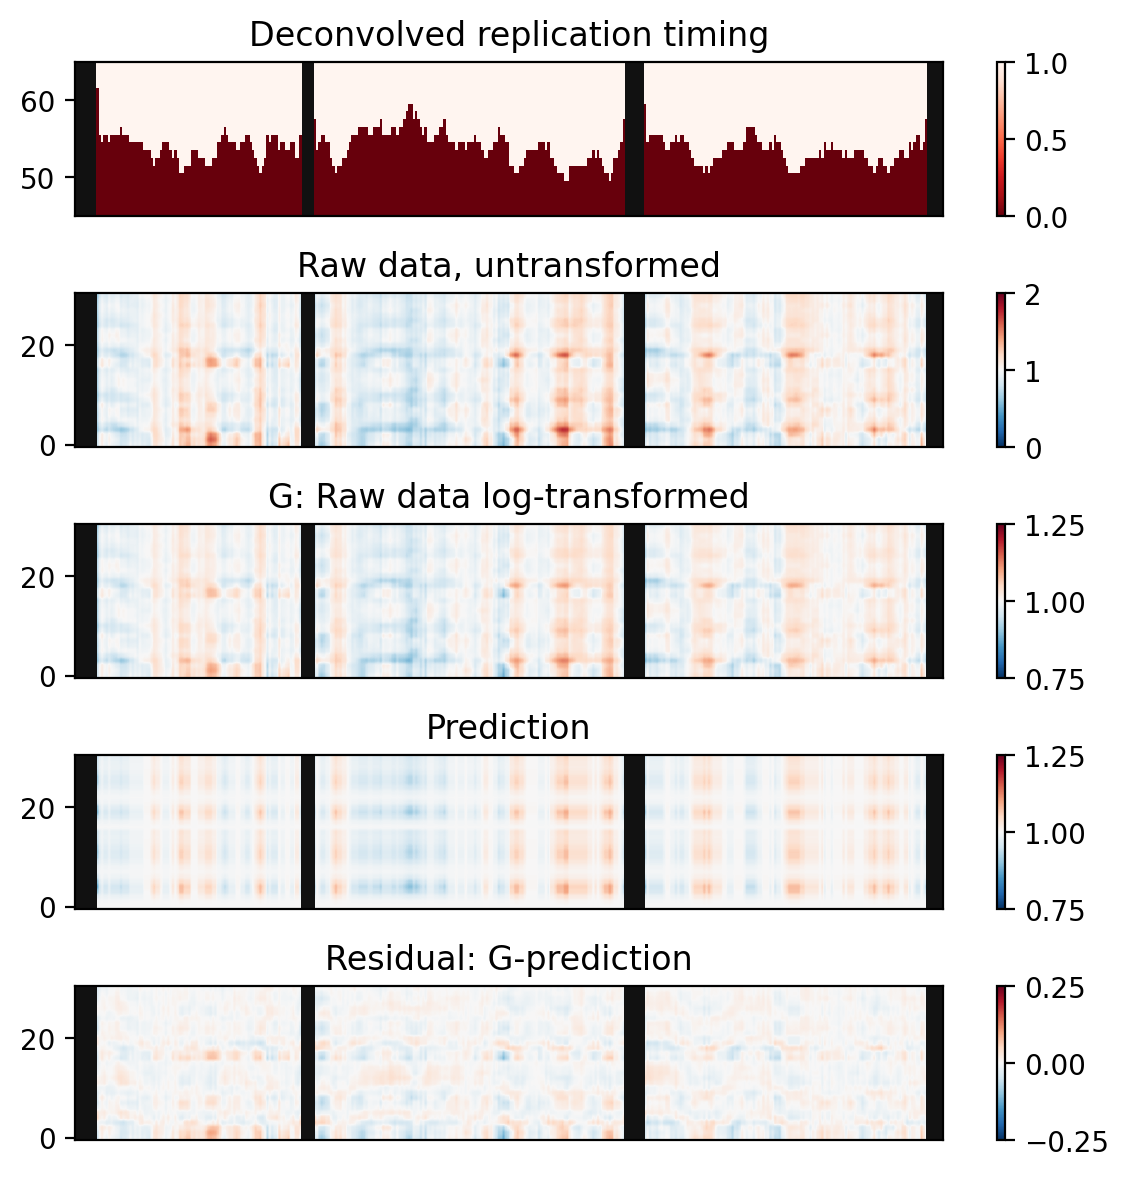

In [1893]:
combined_deconv.plot_deconvolution_prediction()

In [1999]:
from src.tf_sites import TFBindingSites

TFBindingSites()

There are 118 MacIsaac TFs
There are 49 cell cycle transcription factors (CCTFs) profiled by Kelliher, 2018
There are 340 transcription factors profiled using ChIP-exo by Rossi, 2021
There are 17 CCTFS in the Rossi dataset.
There are 22 CCTFS in the MacIsaac dataset.


In [2023]:
threshold_indices = real_deconv1.selected_threshold_region.values

replication_indices = np.argmax(real_deconv1.F[:, threshold_indices], axis=0)
thresholded_replication = (real_deconv1.F[:, threshold_indices] > 0.5)

replication_times = np.argmax((real_deconv1.F[:, threshold_indices] > 0.5), axis=0)
idx_sort = np.argsort(replication_times, axis=0)

sorted_replication_mat = thresholded_replication[:, idx_sort]

Text(0.5, 1.0, 'Normalization transform for replication timing')

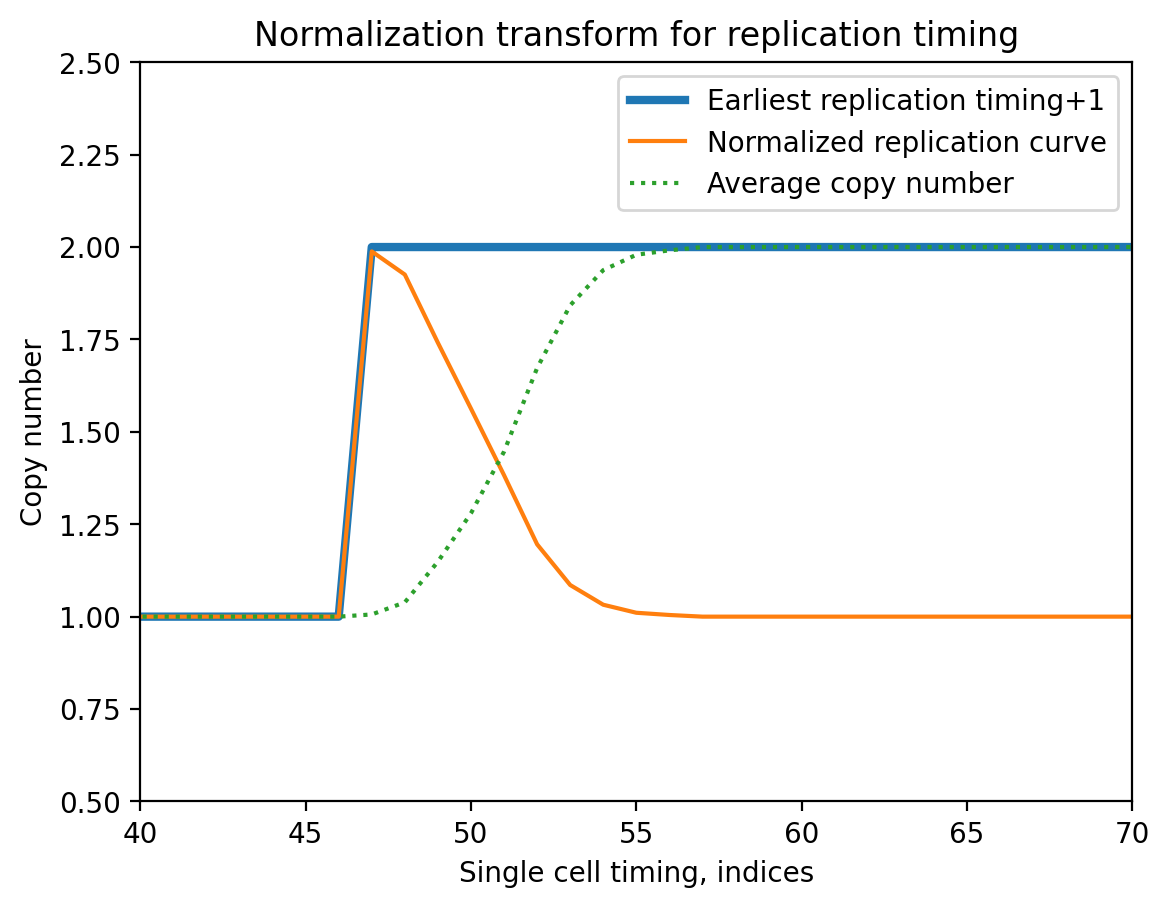

In [2000]:
replication_timing_curve = sorted_replication_mat[:, 0]
avg_curve = sorted_replication_mat.mean(axis=1)

plt.plot(replication_timing_curve = sorted_replication_mat[:, 0], label="")
plt.plot(replication_timing_curve+1, lw=3,  label="Earliest replication timing+1")
plt.plot((replication_timing_curve+1) / (avg_curve+1), label="Normalized replication curve")
plt.plot(avg_curve+1, ls='dotted', label="Average copy number")
plt.xlim(40, 70)
plt.ylim(0.5, 2.5)
plt.legend()
plt.ylabel("Copy number")
plt.xlabel("Single cell timing, indices")
plt.title("Normalization transform for replication timing")


0

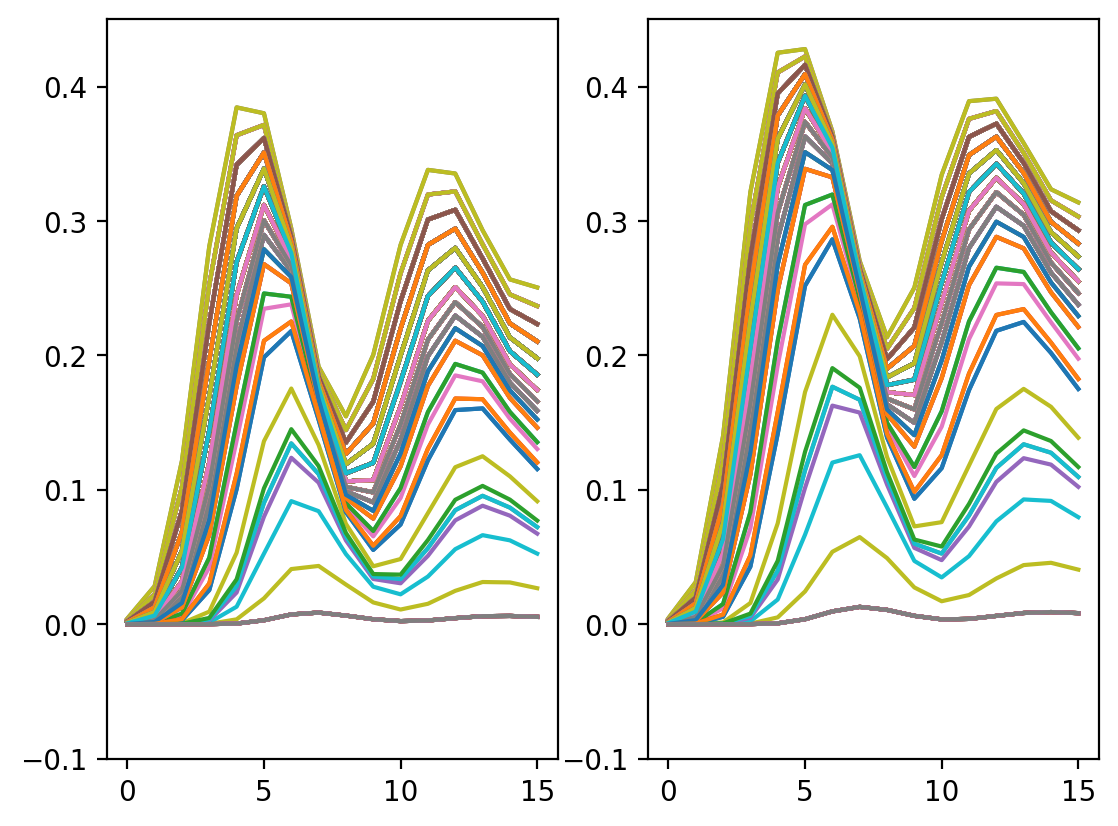

In [2408]:
avg_curve = real_deconv1.rough_average_copy_curve
norm_HF = H @ avg_curve

F = real_deconv1.F
real_deconv1.F.shape

plt.subplot(1, 2, 1)
plt.plot(H @ (F / avg_curve.reshape((-1, 1))))
plt.ylim(-0.1, 0.45)

plt.subplot(1, 2, 2)
plt.plot((H @ F) / norm_HF.reshape((-1, 1)))
plt.ylim(-0.1, 0.45)
0